# Customer Churn & Retention Analysis  

## Problem Statement

Customer churn is one of the most significant financial challenges for 
subscription-based businesses. For telecommunications companies, where 
acquiring a new customer costs significantly more than retaining an 
existing one, even a modest reduction in churn rate can translate into 
material revenue recovery.

This analysis uses a telecom customer dataset of 7,043 customers to 
identify the key behavioral, demographic, and service-related factors 
that distinguish churned customers from retained ones with the goal 
of surfacing actionable retention strategies.

### Objectives

- Quantify the financial impact of churn on monthly and historical revenue
- Identify which customer segments carry the highest churn risk
- Determine which service and contract features are most strongly associated with retention
- Produce targeted recommendations a retention team could act on

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Understanding the data

Each row represents a customer, each column contains customer’s attributes described on the column Metadata. 

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

The target variable is churn column.


In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [4]:
print("Numeric columns")
display(df.describe())
print("\n Categorical columns")
display(df.describe(include=object))
print("Duplicate rows:", df.duplicated().sum())
print("Churn distribution (%):\n", df["Churn"].value_counts(normalize=True).mul(100).round(2))
print("\nMissing values:\n", df.isnull().sum())

Numeric columns


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



 Categorical columns


C:\Users\arunika\AppData\Local\Temp\ipykernel_19260\3877370751.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=object))


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


Duplicate rows: 0
Churn distribution (%):
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
df.groupby('Contract')["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Contract,,,,,,,,
Month-to-month,3875.0,18.036645,17.689054,1.0,3.0,12.0,29.0,72.0
One year,1473.0,42.044807,19.035883,0.0,27.0,44.0,58.0,72.0
Two year,1695.0,56.735103,18.209363,0.0,48.0,64.0,71.0,72.0


In [6]:
cat_cols = df.select_dtypes(include=object).columns
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

customerID: <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']


C:\Users\arunika\AppData\Local\Temp\ipykernel_19260\992485208.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=object).columns


### Observations

- No duplicate customer records were identified confirming the uniqueness of each customer entry.

- Several variables require semantic interpretation beyond their raw data types to ensure correct analytical treatment.

- The overall customer churn rate is approximately 26.5%.

- Customer tenure values are non-negative and fall within a reasonable range of 0 to 72 months.

- Observed churn behavior aligns with expected business patterns with higher churn concentrated among short-tenure and month-to-month contract customers.

## Data Cleaning

In [7]:
df["SeniorCitizen"] = df["SeniorCitizen"].replace({0: "No", 1: "Yes"})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- TotalCharges column is a the total amount paid by the user so it should be a numeric data type.

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

- We see TotalCharges has 11 missing values. Let's look into the missing rows.

In [10]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


- All these rows have 0 tenture but some value in the monthly charges. Let's check if there are other rows where tenture is 0. 

In [11]:
df[df["tenure"]==0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


- There are no additional missing values in the Tenure column. This suggests that these columns contains new customers that have not been billed yet. SO we are going to replace the missing values with 0.

In [12]:
df.loc[df["tenure"] == 0, "TotalCharges"]=0
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
col = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','MultipleLines']
df[col] = df[col].astype('category')
df.dtypes

customerID               str
gender                   str
SeniorCitizen         object
Partner                  str
Dependents               str
tenure                 int64
PhoneService             str
MultipleLines       category
InternetService          str
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract                 str
PaperlessBilling         str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges         float64
Churn                    str
dtype: object

In [14]:
df["Churn_Binary"] = (df["Churn"] == "Yes").astype(int)
df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0–12 mo", "13–24 mo", "25–48 mo", "49–72 mo"],
    include_lowest=True
)
df["Tenure_Group"].value_counts().sort_index()

Tenure_Group
0–12 mo     2186
13–24 mo    1024
25–48 mo    1594
49–72 mo    2239
Name: count, dtype: int64

In [18]:
print(f"Final shape: {df.shape}")

Final shape: (7043, 23)


## Key performace indicators

Key performance indicators (KPIs) calculated before conducting exploratory data analysis to establish a baseline for evaluating churn patterns across customer segments.

In [15]:
total_customers   = len(df)
churned_customers  = (df["Churn"] == "Yes").sum()
retained_customers = total_customers - churned_customers

churn_rate        = churned_customers / total_customers # the percentage of customers who have discontinued their subscription
retention_rate    = 1 - churn_rate # the percentage of customers who remain active
avg_tenure        = df["tenure"].mean() # the average monthly revenue generated per customer
arpu              = df["MonthlyCharges"].mean() # average revenue generated per user
total_revenue     = df["TotalCharges"].sum() # estimate of the proportion of total historical revenue contributed by customers who churned
churned_revenue   = df.loc[df["Churn"] == "Yes", "TotalCharges"].sum()
revenue_churn_pct = churned_revenue / total_revenue * 100

# Monthly revenue lost to churn
avg_monthly_churned = df.loc[df["Churn"] == "Yes", "MonthlyCharges"].mean()
monthly_rev_lost    = avg_monthly_churned * churned_customers

kpis = {
    "Total Customers":          f"{total_customers:,}",
    "Churned Customers":        f"{churned_customers:,}",
    "Churn Rate":               f"{churn_rate*100:.2f}%",
    "Retention Rate":           f"{retention_rate*100:.2f}%",
    "Avg Customer Tenure":      f"{avg_tenure:.1f} months",
    "ARPU (Monthly)":           f"${arpu:.2f}",
    "Total Historical Revenue": f"${total_revenue:,.0f}",
    "Revenue from Churned":     f"${churned_revenue:,.0f}",
    "Revenue Churn %":          f"{revenue_churn_pct:.1f}%",
    "Est. Monthly Rev. Lost":   f"${monthly_rev_lost:,.0f}",
}

kpi_df = pd.DataFrame(kpis.items(), columns=["KPI", "Value"])
kpi_df.style.set_properties(**{"text-align": "left"}).hide(axis="index")

KPI,Value
Total Customers,"7,043"
Churned Customers,"1,869"
Churn Rate,26.54%
Retention Rate,73.46%
Avg Customer Tenure,32.4 months
ARPU (Monthly),$64.76
Total Historical Revenue,"$16,056,169"
Revenue from Churned,"$2,862,927"
Revenue Churn %,17.8%
Est. Monthly Rev. Lost,"$139,131"


## Observations

The overall churn rate is 26.54% which means around 1 out of 4 customers did not stay. This represents 1869 out of 7043 customers lost. In a subscription-based business model, customer churn directly impacts recurring revenue and long-term profitability.
Understanding the characteristics and behavior of churned customers is therefore essential for improving customer retention strategies.

Revenue churn is at 17.8%, notably lower than the customer churn rate of 26.54%. This divergence suggests that the customers are being lost toward lower-value segments while higher-spending customers are demonstrating comparatively stronger loyalty. 

The average customer tenure of 32.4 months indicates that when customers do commit, they tend to stay for a meaningful period (nearly three years). This points to a service that delivers sustained customer value and implies the churn problem may be concentrated in early lifecycle stages rather than spread evenly across the customer base. An early-cohort drop-off pattern is a common pattern that is worth investigating.

At an average revenue per user (ARPU) of $64.76 per month, customer churn results in an estimated $139,131 in lost monthly recurring revenue. If this trend continues, the cumulative impact will steadily weaken the company’s revenue base over time. Additionally, churned customers have already accounted for approximately $2.86M in lost revenue out of the company’s $16M total historical revenue highlighting the significant financial impact of customer churn.

### Exploratory Data Analysis

1. When do customers churn?

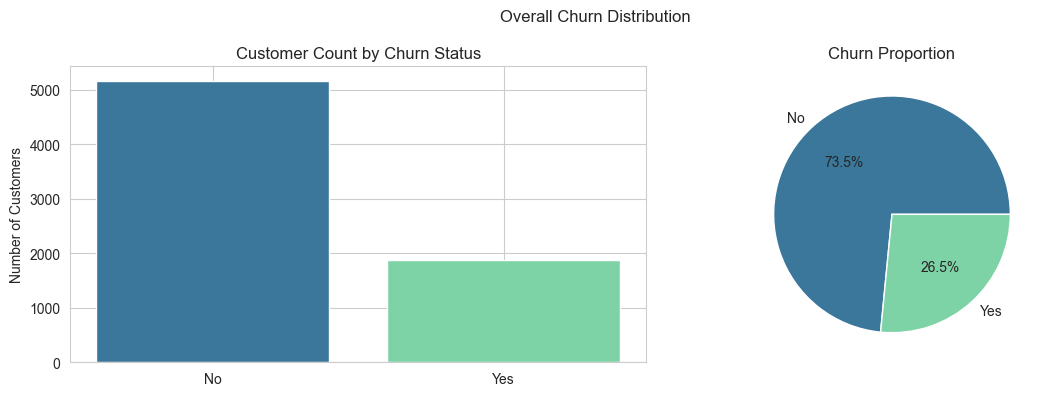

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["Churn"].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=["#3A779B", "#7ED3A6"])
axes[0].set_title("Customer Count by Churn Status")
axes[0].set_ylabel("Number of Customers")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",  colors=["#3A779B", "#7ED3A6"])
axes[1].set_title("Churn Proportion")

plt.suptitle("Overall Churn Distribution")
plt.tight_layout()
plt.show()

The overall churn rate is 26.5% indicating a significant retention problem. With 1869 churned customers out of 7043, reducing churn even by a few percentage points could recover substantial monthly revenue for the business.

2. When do customers churn? Early in their subscription or later?

Churn rate by tenure group:
 Tenure_Group
0–12 mo     47.44
13–24 mo    28.71
25–48 mo    20.39
49–72 mo     9.51
Name: Yes, dtype: float64


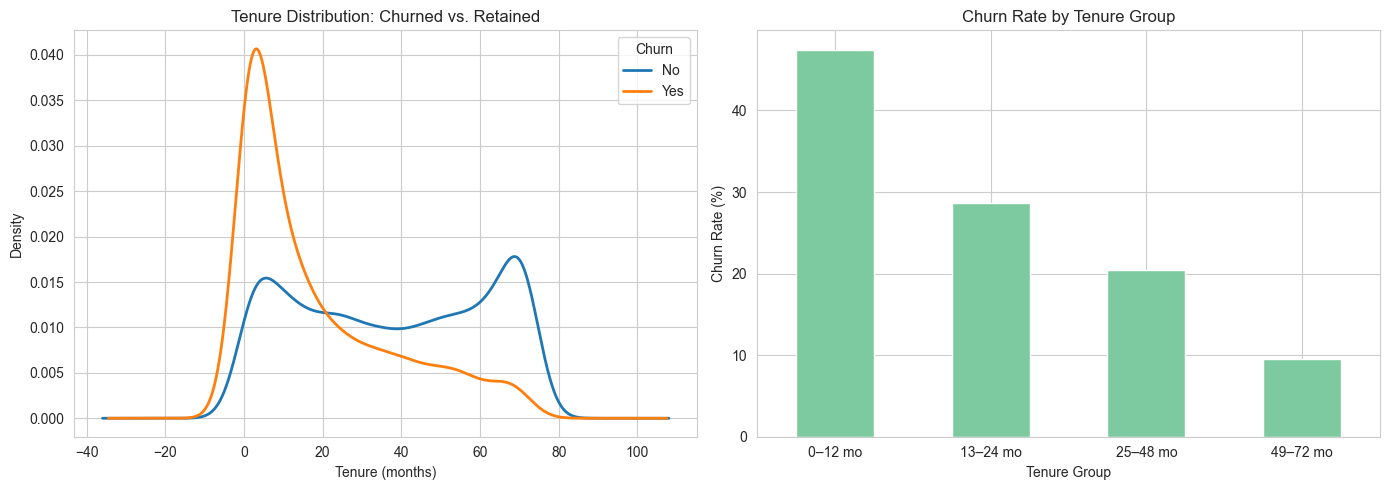

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, grp in df.groupby("Churn"):
    grp["tenure"].plot.kde(ax=axes[0], label=label, linewidth=2)
axes[0].set_title("Tenure Distribution: Churned vs. Retained")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Density")
axes[0].legend(title="Churn")

churn = (df.groupby("Tenure_Group")["Churn"].value_counts(normalize=True).unstack().mul(100))
churn["Yes"].plot(kind="bar", ax=axes[1], color="#7DCAA0", edgecolor="white", rot=0)
axes[1].set_title("Churn Rate by Tenure Group")
axes[1].set_xlabel("Tenure Group")
axes[1].set_ylabel("Churn Rate (%)")
print("Churn rate by tenure group:\n", churn["Yes"].round(2))

plt.tight_layout()
plt.show()

Customers with lower tenure show significantly higher churn rates while customers who stay longer are much more likely to continue using the service. This suggests that many customers may be leaving during the early stages after joining, possibly due to unmet expectations or dissatisfaction with the initial experience. The business should therefore focus more on retaining new customers during their first few months through better onboarding, support and engagement strategies.

3. Does the type of contract a customer is on affect how likely they are to churn?

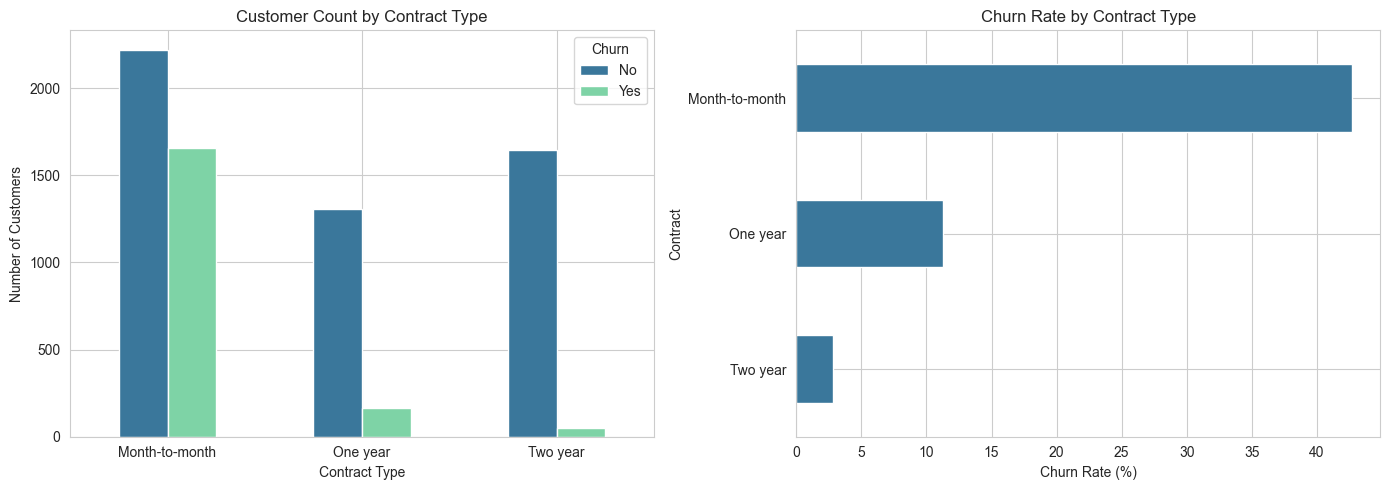

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#raw counts
contract_counts = df.groupby(["Contract", "Churn"]).size().unstack(fill_value=0)
contract_counts.plot(kind="bar", ax=axes[0], color=["#3A779B", "#7ED3A6"], rot=0)
axes[0].set_title("Customer Count by Contract Type")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Number of Customers")
axes[0].legend(title="Churn")

#churn rate
contract_churn = (df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack().mul(100))
contract_churn["Yes"].sort_values().plot(kind="barh", ax=axes[1], color="#3A779B")
axes[1].set_title("Churn Rate by Contract Type")
axes[1].set_xlabel("Churn Rate (%)")

plt.tight_layout()
plt.show()
contract_churn



Customers with month-to-month contracts exhibit significantly higher churn rates at around 43% compared to customers on one-year or two-year contracts. This suggests that customers without long-term contracts are more likely to leave the service as the absence of contractual commitment lowers the barrier to switching providers. The sharp decline in churn among long-term contract customers indicates that promoting annual or multi-year plans could be an effective customer retention strategy.

4. Do demographic characteristics like gender, age, partner status affect churn?


gender
Female    26.92
Male      26.16
Name: Yes, dtype: float64%

SeniorCitizen
Yes    41.68
No     23.61
Name: Yes, dtype: float64%

Partner
No     32.96
Yes    19.66
Name: Yes, dtype: float64%

Dependents
No     31.28
Yes    15.45
Name: Yes, dtype: float64%


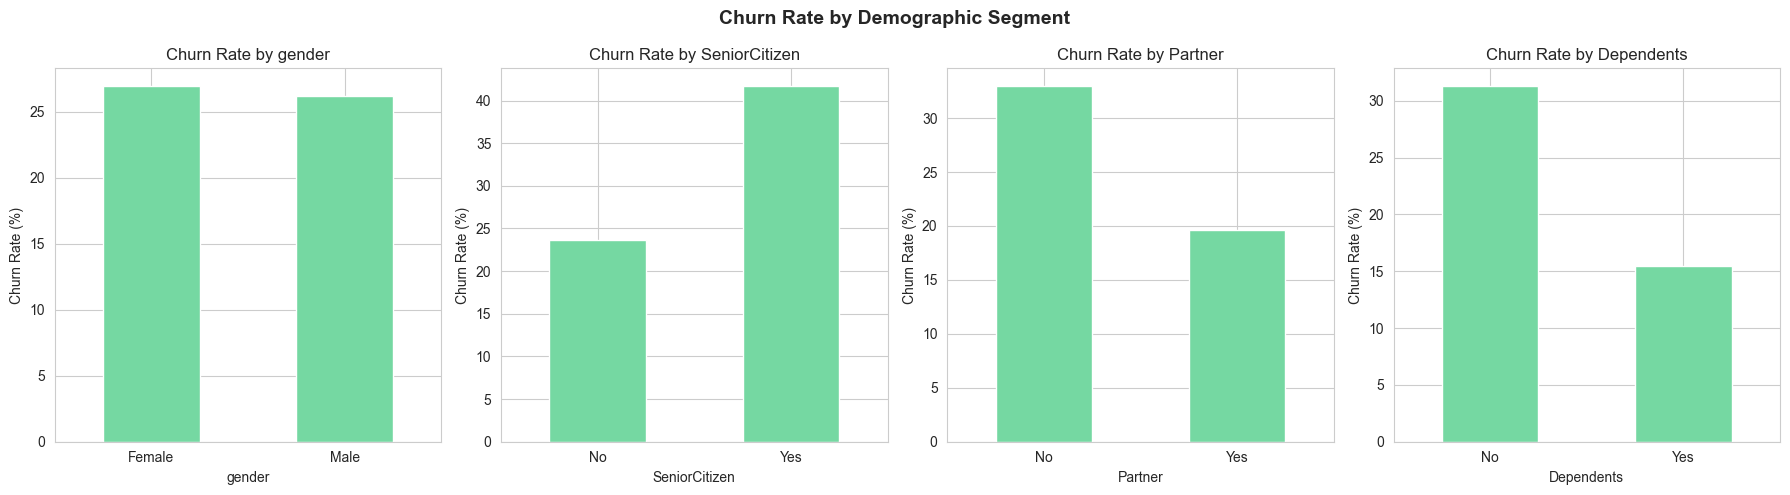

In [29]:
demo_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, col in zip(axes, demo_cols):
    churn_by_col = (df.groupby(col)["Churn"].value_counts(normalize=True).unstack().mul(100))
    churn_by_col["Yes"].plot(kind="bar", ax=ax,color="#75D8A2", rot=0)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel(col)
    print(f"\n{churn_by_col['Yes'].sort_values(ascending=False).round(2)}%")  

plt.suptitle("Churn Rate by Demographic Segment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Senior citizens churn at 42% nearly double the rate of non-seniors making them a high risk segment. This pattern may suggest that older customers experience different challenges or expectations compared to other customer groups which could be related to service accessibility, support experience or overall ease of use.
Unlike some other churn drivers, this segment may not respond primarily to pricing-based retention strategies. Instead, improving customer support, simplifying communication and providing more personalized assistance could potentially help improve retention among senior customers.

5. Does the type of internet service a customer uses affect churn?


Churn Rate by Internet Service:
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Yes, dtype: float64%


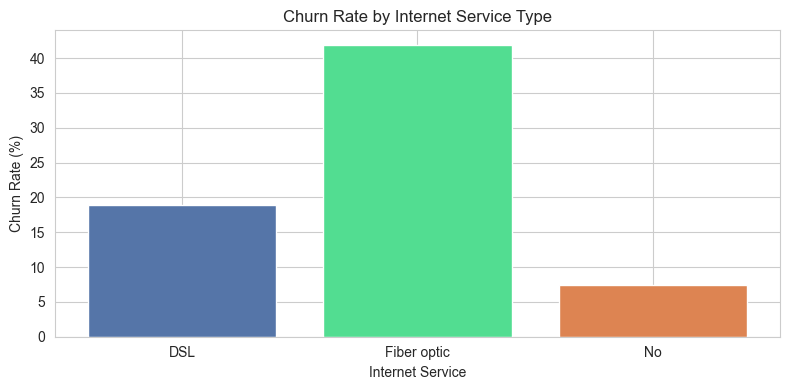

In [30]:
internet_churn = (df.groupby("InternetService")["Churn"].value_counts(normalize=True).unstack().mul(100))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(internet_churn.index, internet_churn["Yes"],color=["#5575A8", "#52DD91", "#DD8452"])
ax.set_title("Churn Rate by Internet Service Type")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn Rate (%)")
print(f"\nChurn Rate by Internet Service:\n{internet_churn['Yes'].sort_values(ascending=False).round(2)}%") 

plt.tight_layout()
plt.show()

In [38]:
df.groupby("InternetService")["MonthlyCharges"].mean()

InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64

Fiber optic customers pay an average of $91.50 per month generating substantially higher average monthly revenue than DSL plans and yet they account for a disproportionately higher share of churn. This undermines the assumption that higher-paying customers are more invested in the service.
One possible explanation is that customers paying premium prices may also carry higher expectations around service quality, reliability, and overall experience. As a result, dissatisfaction within this segment could translate into faster churn despite the higher revenue contribution.
For the business, this represents a high-impact retention segment. Losing a fiber optic customer results in 1.6x more in monthly revenue loss compared to losing a DSL customer, making it important to further investigate the drivers of dissatisfaction and churn within this group.

6. Do add-on services like OnlineSecurity, TechSupport etc. affect churn?


Churn Rate by OnlineSecurity:
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Yes, dtype: float64

Churn Rate by OnlineBackup:
OnlineBackup
No                     39.93
No internet service     7.40
Yes                    21.53
Name: Yes, dtype: float64

Churn Rate by TechSupport:
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Yes, dtype: float64


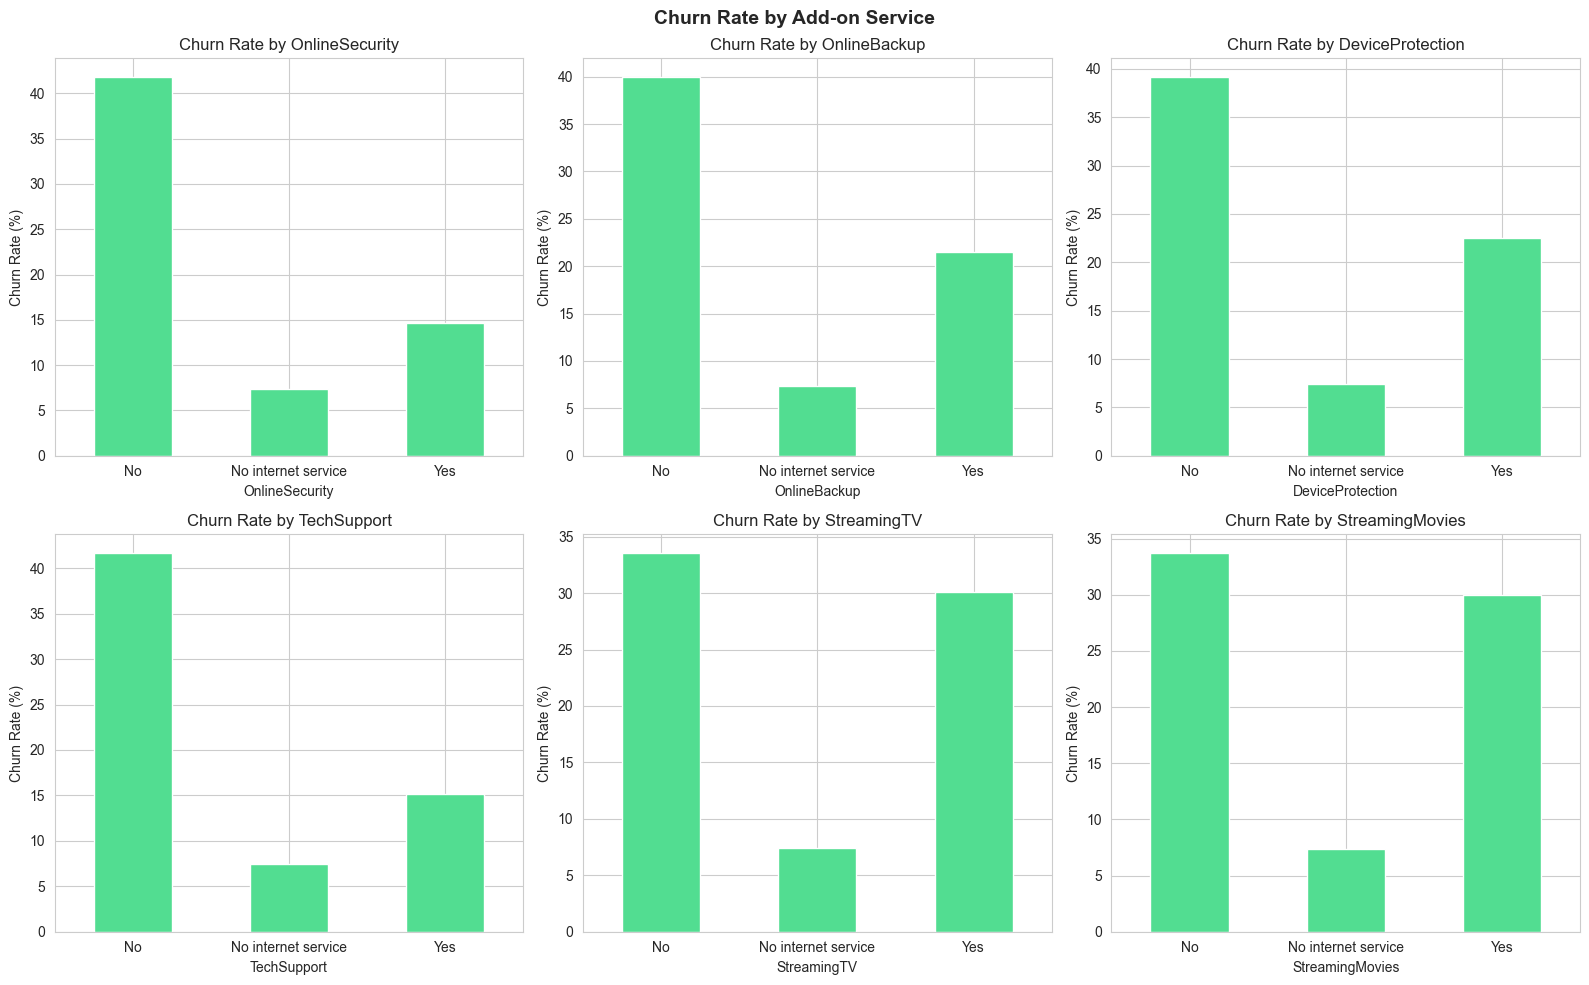

In [31]:
add_on_services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flat, add_on_services):
    churn_by_svc = (df.groupby(col)["Churn"].value_counts(normalize=True).unstack().mul(100))
    churn_by_svc["Yes"].plot(kind="bar", ax=ax,color="#52DD91", rot=0)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
for col in ["OnlineSecurity", "OnlineBackup", "TechSupport"]:
    result = (df.groupby(col)["Churn"].value_counts(normalize=True).unstack().mul(100))
    print(f"\nChurn Rate by {col}:")
    print(result["Yes"].round(2))
plt.suptitle("Churn Rate by Add-on Service", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Customers without OnlineSecurity and TechSupport churn at approximately 42%, compared to around 15% for customers who subscribe to these services, nearly three times the rate. OnlineBackup shows a similar pattern (40% vs 22%), while streaming services show relatively little difference in churn behavior.
This may suggest that support-oriented services contribute more strongly to customer retention than entertainment-focused add-ons. Customers using security and technical support services may feel more integrated into the platform or receive greater ongoing value from the service experience.
Since churn is most concentrated within the first 12 months, introducing these services earlier in the customer lifecycle such as through discounted onboarding bundles could potentially help improve retention among newer customers.

7. Do higher charges lead to more churn?

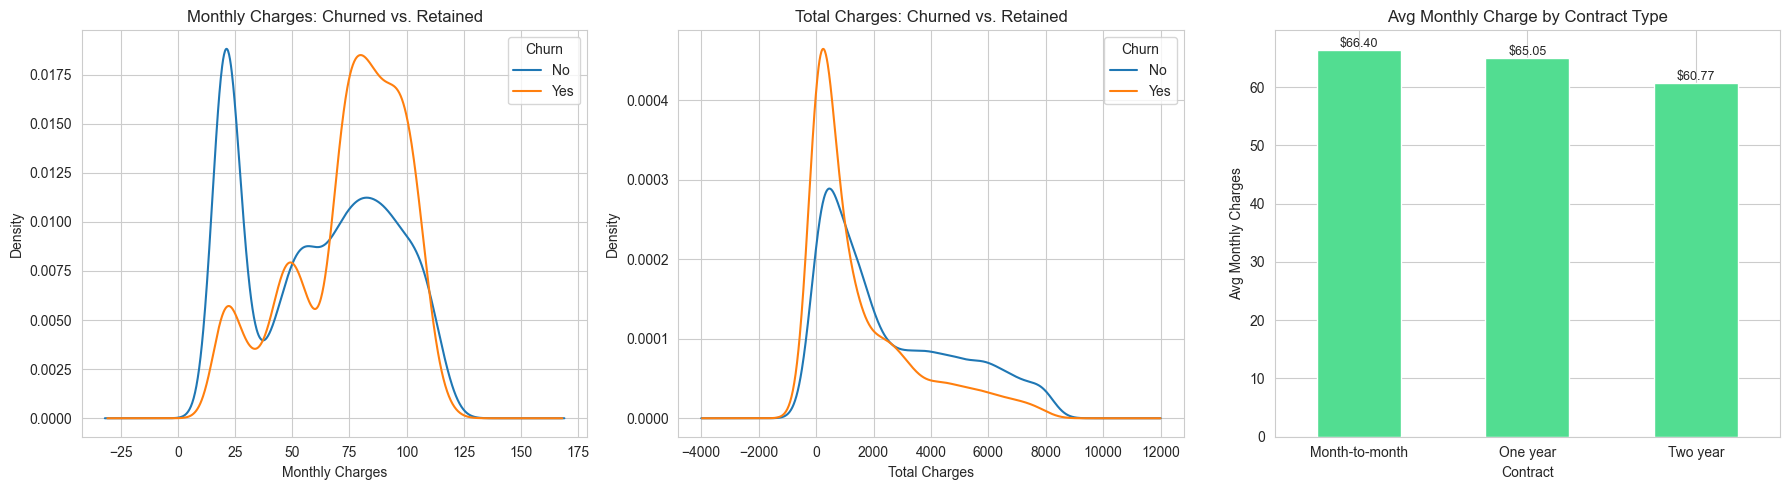

Avg Monthly Charges (Churned)  : $ 74.44
Avg Monthly Charges (Retained) : $ 61.27


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# First chart - monthly charges
for label, grp in df.groupby("Churn"):
    grp["MonthlyCharges"].plot.kde(ax=axes[0], label=label)
axes[0].set_title("Monthly Charges: Churned vs. Retained")
axes[0].set_xlabel("Monthly Charges")
axes[0].set_ylabel("Density")
axes[0].legend(title="Churn")

# Second chart - total charges
for label, grp in df.groupby("Churn"):
    grp["TotalCharges"].clip(upper=8000).plot.kde(ax=axes[1], label=label)
axes[1].set_title("Total Charges: Churned vs. Retained")
axes[1].set_xlabel("Total Charges")
axes[1].legend(title="Churn")

# Third chart - avg monthly charge by contract
avg_charge = df.groupby("Contract")["MonthlyCharges"].mean()
avg_charge.plot(kind="bar", ax=axes[2], color="#52DD91", edgecolor="white", rot=0)
axes[2].set_title("Avg Monthly Charge by Contract Type")
axes[2].set_ylabel("Avg Monthly Charges")
for p in axes[2].patches:
    axes[2].annotate(f"${p.get_height():.2f}",(p.get_x() + p.get_width()/2, p.get_height() + 0.5),ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Avg Monthly Charges (Churned)  : $", round(df[df["Churn"]=="Yes"]["MonthlyCharges"].mean(), 2))
print("Avg Monthly Charges (Retained) : $", round(df[df["Churn"]=="No"]["MonthlyCharges"].mean(), 2))

Churned customers pay higher monthly charges on average ($74) compared to retained customers ($61). Yet their total charges are much lower 
because they leave early before accumulating significant billing history. This combination — high monthly cost, short tenure — strongly suggests 
price sensitivity is a key driver of churn. Customers who feel they are overpaying are more likely to switch to a competitor. This is further 
supported by the high churn rate among fiber optic customers who pay the highest monthly rates.

8. Does the way a customer pays their bill affect how likely they are to churn?

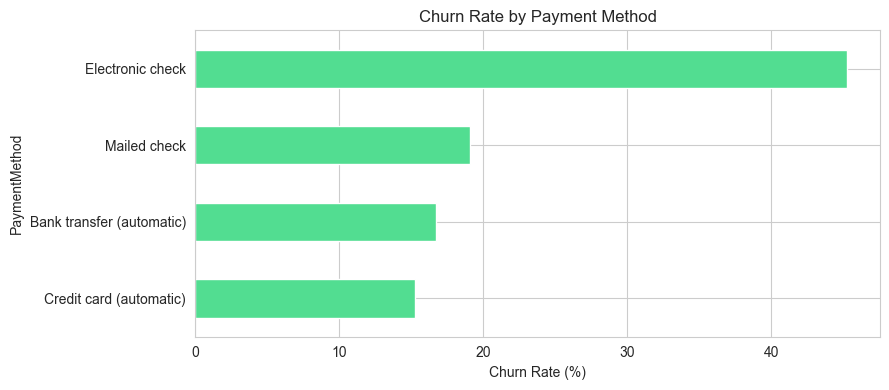


Churn Rate by Payment Method:
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Yes, dtype: float64


In [33]:
payment_churn = (df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack().mul(100))

fig, ax = plt.subplots(figsize=(9, 4))
payment_churn["Yes"].sort_values().plot(kind="barh", ax=ax, color="#52DD91")
ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

print("\nChurn Rate by Payment Method:")
print(payment_churn["Yes"].sort_values(ascending=False).round(2))

Customers using electronic check payment methods show noticeably higher churn rates compared to customers using automatic payment options such as bank transfers or credit cards.
This pattern may suggest that customers enrolled in automatic payment systems are more integrated into the service ecosystem and therefore less likely to discontinue the service abruptly. In contrast, customers making manual payments may face lower switching friction and weaker long-term engagement.
From a business perspective, encouraging customers to adopt automatic payment methods could potentially improve retention while also increasing payment consistency and operational efficiency.

9. Which features have the strongest relationship with churn?

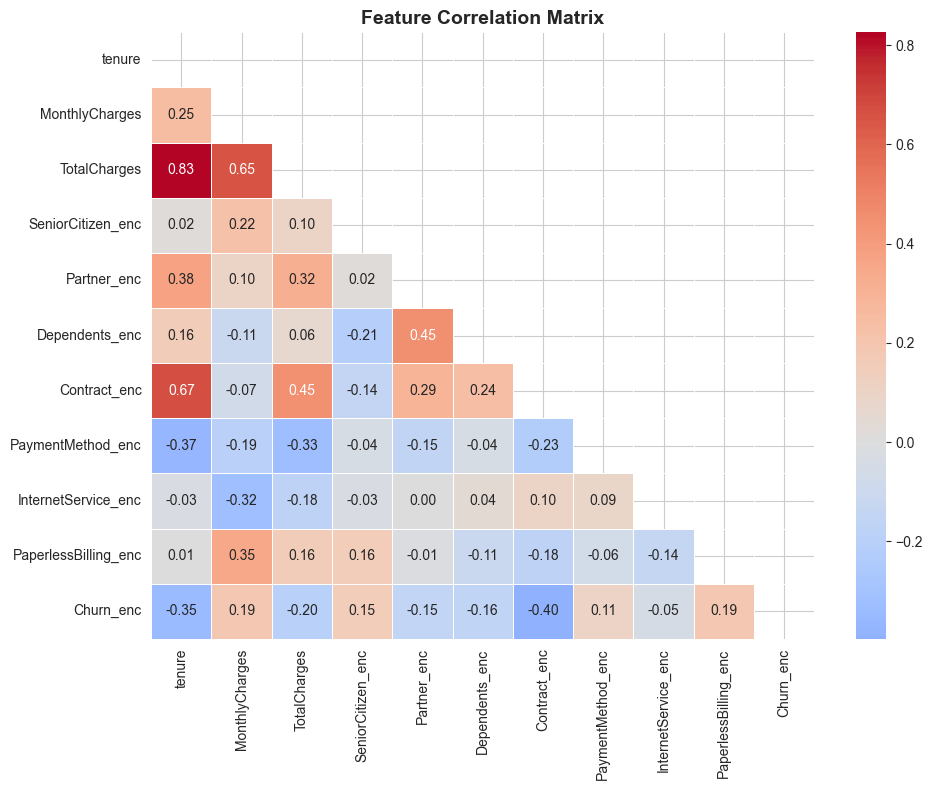

In [34]:
from sklearn.preprocessing import LabelEncoder

encode_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", 
               "PaperlessBilling", "Contract", "PaymentMethod", "InternetService"]

df_encoded = df.copy()
le = LabelEncoder()
for col in encode_cols + ["Churn"]:
    df_encoded[col + "_enc"] = le.fit_transform(df_encoded[col].astype(str))

numeric_feats = ["tenure", "MonthlyCharges", "TotalCharges","SeniorCitizen_enc", "Partner_enc", "Dependents_enc",
                 "Contract_enc", "PaymentMethod_enc","InternetService_enc", "PaperlessBilling_enc", "Churn_enc"]

corr = df_encoded[numeric_feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Contract type has the strongest negative correlation with churn which means customers on longer contracts are significantly less likely to leave. 
Tenure is also strongly negatively correlated confirming that loyalty builds over time. MonthlyCharges has a positive correlation with churn 
— the more a customer pays per month the higher their churn risk. TotalCharges is negatively correlated because it is essentially a proxy for tenure — customers who have paid more in total have simply been with the company longer and are therefore more loyal.

10. Can we combine everything we have learned to identify the single most at-risk customer segment?

In [35]:
high_risk = df[
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] <= 12) &
    (df["InternetService"] == "Fiber optic") &
    (df["PaymentMethod"] == "Electronic check")
]

total_high_risk      = len(high_risk)
churned_high_risk    = (high_risk["Churn"] == "Yes").sum()
churn_rate_high_risk = churned_high_risk / total_high_risk * 100

print(f"High Risk Segment Size   : {total_high_risk} customers")
print(f"Churned in Segment       : {churned_high_risk} customers")
print(f"Churn Rate (High Risk)   : {churn_rate_high_risk:.1f}%")
print(f"Overall Churn Rate       : {churn_rate*100:.1f}%")

High Risk Segment Size   : 631 customers
Churned in Segment       : 449 customers
Churn Rate (High Risk)   : 71.2%
Overall Churn Rate       : 26.5%


By combining the four strongest churn predictors: month-to-month contract, tenure under 12 months, fiber optic internet and electronic check payment, we identify a high risk segment that churns at nearly 3x the overall rate. Although this group represents a small portion of the customer base, targeting them with a retention offer such as a contract upgrade incentive or autopay discount could have an outsized mpact on overall churn reduction.

## Key Findings

After analyzing 7043 customers here is what i found:

- Customers on month-to-month contracts churn at 43% compared to 11% on one-year contracts and just 3% on two-year contracts. This suggests that longer-term contracts may increase customer retention by creating greater financial and psychological commitment, making cancellation a more deliberate decision rather than an immediate one.

- New customers are the most at risk. Almost 1 in 2 customers leave in their first year but after 2 years the churn rate drops below 15%.

- Fiber optic customers churn at approximately 42% despite subscribing to the company’s premium internet service tier. One possible explanation is a mismatch between pricing and customer experience, where customers paying significantly higher monthly charges ($91.50 on average) may also hold higher expectations around reliability, support quality, and overall service experience. As a result, dissatisfaction within this segment could lead to faster churn despite the higher revenue contribution per customer.

- Electronic check users churn at 45% compared to 15% for automatic payment customers. This gap likely reflects engagement depth — customers on autopay have integrated the service into their financial routine, while manual payers retain lower friction to cancel. Migrating customers to automatic billing at onboarding is a low-cost intervention with measurable retention upside.

- Customers without OnlineSecurity and TechSupport churn at 42% vs 15% for those who have them. These services increase switching cost by deepening functional reliance on the platform, when a customer depends on the same provider for security and support, cancellation becomes a more disruptive decision rather than a frictionless one.
  

## What the Business Should Do

Based on this analysis, the three highest-impact retention interventions are:

1. **Convert month-to-month customers to annual contracts.** Contract type 
is the single strongest predictor of churn in this dataset. Customers on 
monthly plans churn at 43% compared to 11% on one-year and 3% on two-year 
contracts. A targeted incentive — a discount, a free add-on, or a locked-in 
rate — offered at the 3–6 month mark could meaningfully shift this distribution.

2. **Invest in the first-year experience.** Nearly 1 in 2 customers leave 
within their first 12 months. A structured onboarding programme that includes 
proactive support outreach, an introductory bundle with OnlineSecurity and 
TechSupport, and early check-ins would target churn at its highest concentration 
point.

3. **Migrate electronic check users to automatic payments at onboarding.** 
Electronic check customers churn at 45% compared to 15% for autopay users — 
a 30 percentage point gap that reflects disengagement as much as payment 
preference. Defaulting new customers to autopay with an opt-out, rather than 
opt-in, is a low-cost structural change with measurable retention upside.